# IS4487 Week 4 - Assignment

### Outline

Our Goals with this Project:

1. Import and review the data
2. Perform EDA and Clean Data

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_04_data_understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Business Case: AdviseInvest
You work on a small team of data analysts at AdviseInvest, a venture-backed startup. The Director of Sales at AdviseInvest has approached your team asking for help solving a staffing problem.

### The Company
The company's mission is to provide tools and support to help ordinary people gain control of their personal finances. The company leverages technology to provide affordable financial advice to a national client base.

Customers who reach AdviseInvest's website go through five steps:

- Open an account.
- Complete a customer profile form with basic information about their background and finances.
- Schedule a free phone conversation with a sales representative during a 1-hour window of time.
- Attend the free phone conversation.
- Buy a financial plan.
- There are three types of financial plans: Beginner, Intermediate, and Advanced. Each is sold at a different price, and there are varying degrees of personalization. After a customer purchases a financial plan, the customer is assigned a financial planner who helps determine the customer's goals and advises the customer on spending decisions.

### The Problem
Some customers are lost at each stage of the process. Steps 3 and 4 are particularly challenging because approximately 50% of those who schedule a phone conversation fail to pick up the call. This leads to inefficiencies from a staffing perspective.

AdviseInvest has 4 sales reps on staff during each particular 1-hour window. Each of the 4 reps is assigned 2 prospective customers per hour, which means that the company schedules a total of 8 phone calls per hour. The calls are outgoing: sales reps call customers who scheduled a phone conversation during that hour window.

Unfortunately, as noted above, many of the customers who scheduled a call do not answer. As a consequence, sales reps are often left underutilized. Moreover, they are underutilized unevenly. For example, it is possible that one sales rep will not do any sales calls during that hour, whereas another will be busy the entire hour with two calls. Sales reps have nothing to do when customers do not answer the scheduled phone call.

For this assignment, the variable `answered` is your target.  

### AdviseInvest Data Dictionary

| Variable | Description | Type | Code |
|:---|:---|:---|:---|
| customer_id | Unique customer identifier | Numeric | |
| Answered | Customer response | Binary | 0: customer did not answer scheduled call; 1: customer answered scheduled call |
| Income | Customer income in US dollars | Numeric | |
| Female | Customer gender | Binary | 0: female; 1: male |
| Age | Age in years | Numeric | |
| Job | Nature of job | Categorical | 0 : unemployed; 1 : entry level position; 2 : midlevel position; 3 : management/ self-employed/ highly qualified employee/ officer |
| Num_dependents | Number of people for whom the customer provides maintenance | Numeric | |
| Rent | Customer rents | Binary | 0: no; 1: yes |
| Own_res | Customer owns residence | Binary | 0: no; 1: yes |
| New_car | Recent new car purchase | Binary | New car purchase in the last 3 months: 0: no, 1: yes |
| Chk_acct | Checking account status | Categorical | 0 : no checking account; 1: checking < 200 USD; 2 : 200 < checking < 2000 USD; 3: 2000 < checking < 35000 USD; 4: >= 3500 USD |
| Sav_acct | Average balance in savings account | Categorical | 0 : no savings account; 1 : 100 <= savings < 500 USD; 2 : 500 <= savings < 2000 USD; 3 : 2000 < savings < 35000 USD; 4: >= 3500 USD |
| Num_accts | Number of accounts owned by customer | Numeric | |
| Mobile | Mobile phone | Binary | 0: customer provided non‐mobile phone for follow‐up call; 1: customer provided mobile phone for follow‐up call |
| Product | Type of product purchased after conversation with sales rep | Categorical | 0: customer did not answer call; 1: customer answered but did not purchase a product; 2: customer answered and purchased Beginner plan; 3: customer answered and purchased Intermediate plan; 4: customer answered and purchased Advanced plan |


### Load Libraries

Import the libraries you will need, such as:
- Pandas
- Sklearn
- Matplotlib


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.preprocessing import StandardScaler

pd.set_option('display.width', 120)
plt.rcParams['figure.figsize'] = (8, 5)

## Step 1: Initial Data Understanding

### Do the following:
 1. Import data from the AdviseInvest historical dataset into a dataframe (in GitHub go to the DataSets folder and look for `adviseinvest_historical_data.csv`)
 2. Show the datatypes 
 3. Describe the dataset

 Think about if there are any outliers, missing values, or duplicates.  We will cover those topics more next week.  

In [2]:
# Import the data
url = 'https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/main/DataSets/adviseinvest_historical_data.csv'
df = pd.read_csv(url)

print(f"Rows: {df.shape[0]:,}   Columns: {df.shape[1]}")
df.head()

Rows: 29,504   Columns: 15


,customer_id,answered,income,female,age,job,num_dependents,rent,own_res,new_car,chk_acct,sav_acct,num_accts,mobile,product
0,10098,0,-65600,0,24,2,1,0,1,1.0,1,1,3,0,0
1,184,0,4330,0,24,2,2,1,0,0.0,1,3,1,0,0
2,194,0,4330,0,22,2,1,1,0,0.0,3,0,0,0,0
3,689,0,4330,0,24,2,2,1,0,0.0,1,3,1,0,0
4,811,0,4330,0,22,2,1,1,0,0.0,3,0,0,0,0


In [3]:
# View the datatypes
df.dtypes

customer_id         int64
answered            int64
income              int64
female             object
age                 int64
job                 int64
num_dependents      int64
rent                int64
own_res             int64
new_car           float64
chk_acct            int64
sav_acct            int64
num_accts           int64
mobile              int64
product             int64
dtype: object

In [4]:
# Describe the data
df.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,29504.0,14850.475563,8517.254310,99.0,7474.75,14850.5,22226.25,29602.0
answered,29504.0,0.546638,0.497829,0.0,0.00,1.0,1.00,1.0
income,29504.0,33766.893303,29379.202710,-65600.0,13550.00,23310.0,41690.00,159450.0
age,29504.0,34.773454,11.369865,19.0,26.00,32.0,40.00,132.0
job,29504.0,1.915401,0.658183,0.0,2.00,2.0,2.00,3.0
num_dependents,29504.0,1.140998,0.348025,1.0,1.00,1.0,1.00,2.0
rent,29504.0,0.210412,0.407608,0.0,0.00,0.0,0.00,1.0
own_res,29504.0,0.681128,0.466047,0.0,0.00,1.0,1.00,1.0
new_car,29502.0,0.240797,0.427575,0.0,0.00,0.0,0.00,1.0
chk_acct,29504.0,1.468547,1.234727,0.0,0.00,1.0,3.00,3.0


In [5]:
# Additional profiling: missing values, duplicates, and the one non-numeric column
print("Missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\nFully duplicated rows: {df.duplicated().sum()}")
print("\nValues in 'female' (stored as text, not numeric):")
print(df['female'].value_counts(dropna=False))

Missing values:
new_car    2
dtype: int64

Fully duplicated rows: 3

Values in 'female' (stored as text, not numeric):
female
0    27903
1     1600
M        1
Name: count, dtype: int64


Question 1.4: Do you see any variables that have potential outliers?  What indicators do you see the the values are out of the normal range?  (don't worry about using a scientific approach for outliers at this stage; just use your best judgment)

### ✍️ Your Response:
**1.4.** Four variables carry values that cannot be correct, and each announces itself differently in the `describe()` output.

**`income`** has a minimum of -65,600. Income cannot be negative. Two records are affected. The tell is simply that the minimum sits on the wrong side of zero, which no amount of legitimate variation explains.

**`age`** has a maximum of 132. One record. Nobody scheduling a fintech sales call is 132 years old. The tell is the gap between the 75th percentile at 40 and the maximum at 132. A distribution whose middle half runs 26 to 40 should not have a tail reaching three digits, which points to a data entry error or a placeholder value.

**`num_accts`** has a maximum of 3,345 against a median of 2. This is the most extreme case in the file. The standard deviation comes out at 19.5 while the interquartile range is only 2 to 3, and a standard deviation that far above the spread of the middle half is a mathematical signature of a single contaminating value. One customer holding 3,345 accounts is implausible on its face.

**`female`** is not an outlier problem but an encoding problem, and it is the reason the column imports as text instead of a number. A single record contains the letter "M" where every other row holds a 0 or a 1. One malformed character forces the entire column into an object dtype, which blocks arithmetic and most charting until it is fixed. Two further issues sit underneath it: the values are 94.6 percent zeros, an implausible gender split for a national customer base, and the data dictionary codes 0 as female and 1 as male, meaning the column name is the opposite of what it stores.

Two smaller items round it out. `new_car` is missing on 2 records, and 3 rows are complete duplicates of other rows. Neither is large, but duplicates inflate whatever they touch and should be removed rather than ignored.

# Step 2: Begin to Explore the Data

We will learn more about Exploratory Data Analysis (EDA) in Week 5. The following steps are to help you connect the data visualization steps that we practiced last week with the process of data understanding - learning more about the dataset and finding the data quality issues that need to be addressed.   These are the first steps in EDA. 

### Do the following:
- Explore the relationships between the target and independent variables
- Create at least five charts to show the relationships, using different chart types that are approriate to the analysis
- Ensure that all charts are clearly labeled and formatted

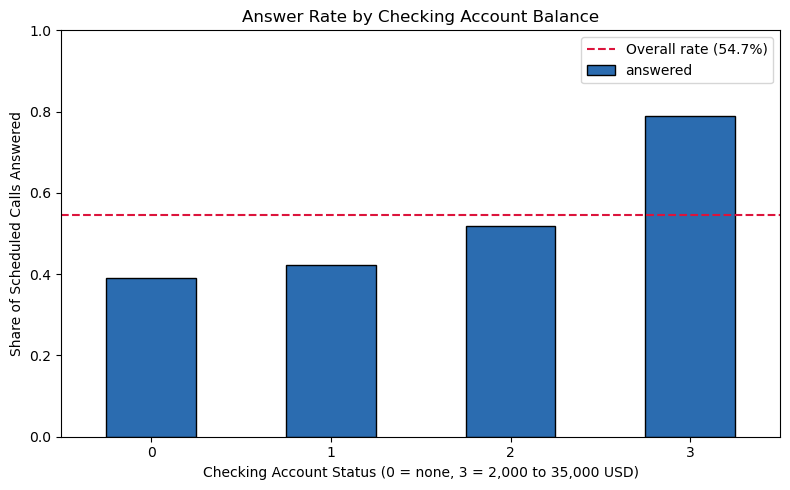

           mean  count
chk_acct              
0         0.391   8512
1         0.421   8960
2         0.519   1728
3         0.789  10304


In [6]:
# Chart 1: Answer rate by checking account status
# chk_acct is coded 0: none, 1: <200 USD, 2: 200-2000 USD, 3: 2000-35000 USD

chk = df.groupby('chk_acct')['answered'].mean()
overall = df['answered'].mean()

ax = chk.plot(kind='bar', color='#2b6cb0', edgecolor='black')
ax.axhline(overall, color='crimson', linestyle='--', label=f'Overall rate ({overall:.1%})')
ax.set_title('Answer Rate by Checking Account Balance')
ax.set_xlabel('Checking Account Status (0 = none, 3 = 2,000 to 35,000 USD)')
ax.set_ylabel('Share of Scheduled Calls Answered')
ax.set_ylim(0, 1)
ax.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(df.groupby('chk_acct')['answered'].agg(['mean', 'count']).round(3))

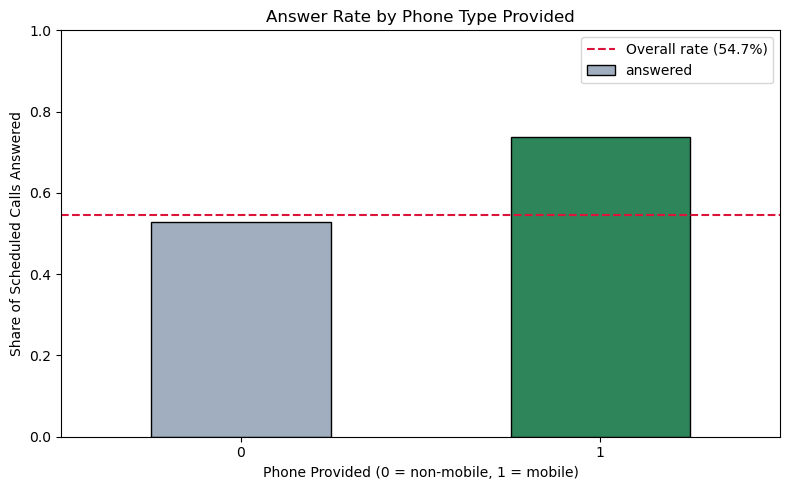

         mean  count
mobile              
0       0.527  26816
1       0.738   2688


In [7]:
# Chart 2: Answer rate by phone type

mob = df.groupby('mobile')['answered'].mean()

ax = mob.plot(kind='bar', color=['#a0aec0', '#2f855a'], edgecolor='black')
ax.axhline(overall, color='crimson', linestyle='--', label=f'Overall rate ({overall:.1%})')
ax.set_title('Answer Rate by Phone Type Provided')
ax.set_xlabel('Phone Provided (0 = non-mobile, 1 = mobile)')
ax.set_ylabel('Share of Scheduled Calls Answered')
ax.set_ylim(0, 1)
ax.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(df.groupby('mobile')['answered'].agg(['mean', 'count']).round(3))

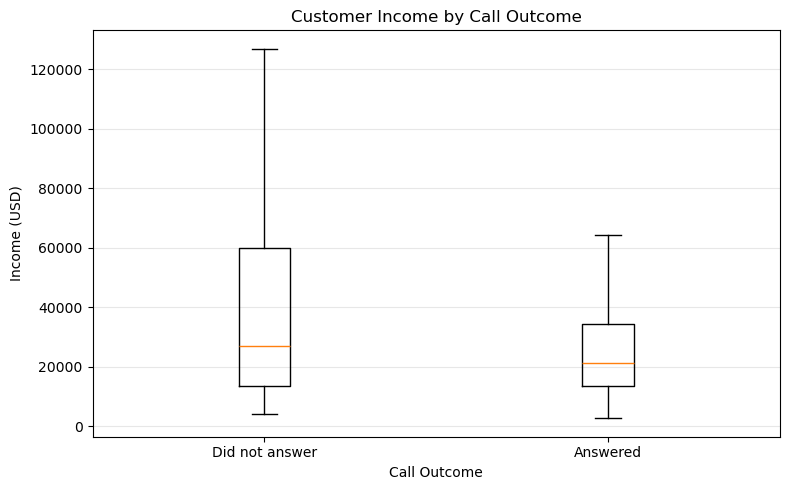

           median     mean  count
answered                         
0         27120.0  40978.0  13375
1         21320.0  27796.0  16127


In [8]:
# Chart 3: Income distribution by whether the customer answered
# Filtering the impossible negative incomes so the boxplot is readable

clean = df[df['income'] >= 0]

data = [clean.loc[clean['answered'] == 0, 'income'],
        clean.loc[clean['answered'] == 1, 'income']]

fig, ax = plt.subplots()
bp = ax.boxplot(data, showfliers=False)
ax.set_xticks([1, 2])
ax.set_xticklabels(['Did not answer', 'Answered'])
ax.set_title('Customer Income by Call Outcome')
ax.set_ylabel('Income (USD)')
ax.set_xlabel('Call Outcome')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(clean.groupby('answered')['income'].agg(['median', 'mean', 'count']).round(0))

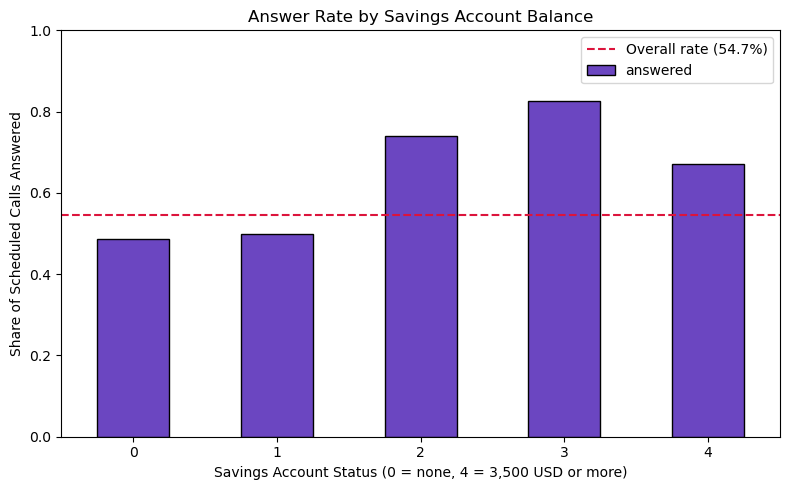

           mean  count
sav_acct              
0         0.486  18816
1         0.500   3200
2         0.741   1728
3         0.826   1472
4         0.672   4288


In [9]:
# Chart 4: Answer rate by savings account balance

sav = df.groupby('sav_acct')['answered'].mean()

ax = sav.plot(kind='bar', color='#6b46c1', edgecolor='black')
ax.axhline(overall, color='crimson', linestyle='--', label=f'Overall rate ({overall:.1%})')
ax.set_title('Answer Rate by Savings Account Balance')
ax.set_xlabel('Savings Account Status (0 = none, 4 = 3,500 USD or more)')
ax.set_ylabel('Share of Scheduled Calls Answered')
ax.set_ylim(0, 1)
ax.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(df.groupby('sav_acct')['answered'].agg(['mean', 'count']).round(3))

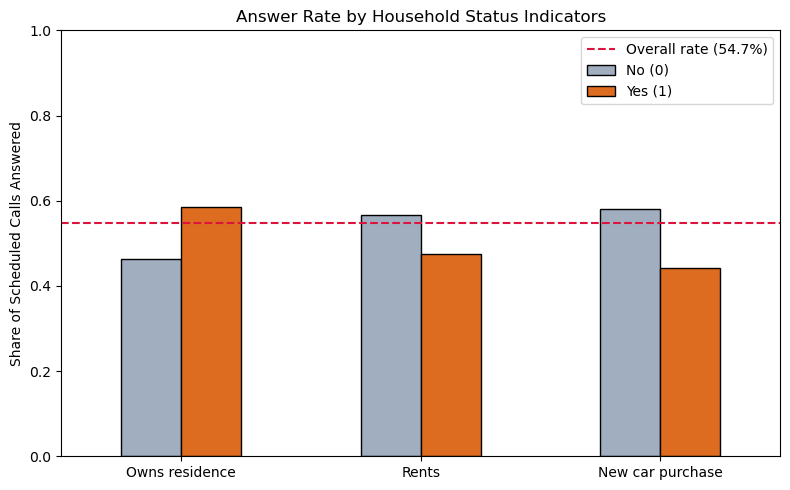

                  No (0)  Yes (1)
Owns residence     0.463    0.586
Rents              0.566    0.474
New car purchase   0.580    0.441


In [10]:
# Chart 5: Answer rate across the binary household indicators

flags = ['own_res', 'rent', 'new_car']
rates = pd.DataFrame({
    'No (0)':  [df.loc[df[f] == 0, 'answered'].mean() for f in flags],
    'Yes (1)': [df.loc[df[f] == 1, 'answered'].mean() for f in flags]
}, index=['Owns residence', 'Rents', 'New car purchase'])

ax = rates.plot(kind='bar', color=['#a0aec0', '#dd6b20'], edgecolor='black')
ax.axhline(overall, color='crimson', linestyle='--', label=f'Overall rate ({overall:.1%})')
ax.set_title('Answer Rate by Household Status Indicators')
ax.set_ylabel('Share of Scheduled Calls Answered')
ax.set_xlabel('')
ax.set_ylim(0, 1)
ax.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(rates.round(3))

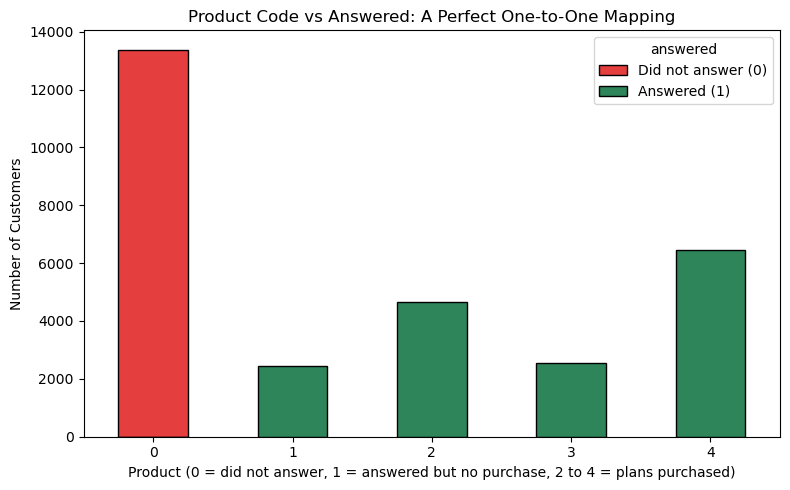

answered      0     1
product              
0         13376     0
1             0  2432
2             0  4672
3             0  2560
4             0  6464

Every product code maps to exactly one outcome. This variable is recorded
after the call and therefore leaks the target.


In [11]:
# Chart 6: Why 'product' cannot be used as a predictor (target leakage)

leak = pd.crosstab(df['product'], df['answered'])

ax = leak.plot(kind='bar', stacked=True, color=['#e53e3e', '#2f855a'], edgecolor='black')
ax.set_title('Product Code vs Answered: A Perfect One-to-One Mapping')
ax.set_xlabel('Product (0 = did not answer, 1 = answered but no purchase, 2 to 4 = plans purchased)')
ax.set_ylabel('Number of Customers')
ax.legend(['Did not answer (0)', 'Answered (1)'], title='answered')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(leak)
print("\nEvery product code maps to exactly one outcome. This variable is recorded")
print("after the call and therefore leaks the target.")

# Step 3: Summarize Your Findings
- Question 3.1: Which variables are NOT useful or applicable to the business need?  (you should reference the target variable and list any variables that are not correlated with the target)

- Question 3.2: Which variables are MOST useful or applicable to the business need, based on the output of your charts?   

- Question 3.3: List at least three ways that the dataset could be improved.  What data quality issues or data types should be fixed?



### ✍️ Your Response:

**3.1 Which variables are NOT useful or applicable to the business need?**

**`product` must be removed, and it is the most important exclusion in the dataset.** The crosstab in Chart 6 is perfectly diagonal: all 13,376 customers coded `product` = 0 did not answer, and all 16,128 customers coded 1 through 4 answered. This is textbook target leakage. `product` records what happened *after* the phone call, so it cannot exist at the moment the scheduling decision is made. A model that included it would score near 100 percent accuracy in testing and would be worthless in production, because on the morning the reps build tomorrow's call list this field is still empty for every prospect. Any variable that only becomes known after the event it predicts belongs out of the feature set.

**`customer_id`** is an arbitrary sequential identifier assigned at signup. It has no causal relationship to whether someone picks up a phone. Including it invites a model to memorize individual records rather than learn a pattern.

**`num_dependents`** carries almost no information. It takes only two values in the entire file, 1 and 2, and the answer rates are 54.8 percent and 53.8 percent. A one point spread against an overall rate of 54.7 percent is noise. A variable with two levels and no separation cannot contribute to a scheduling decision.

**`female`** is unusable in its current state. It imports as text because of a single stray "M", the distribution is 94.6 percent zeros, and the column name contradicts its own coding scheme. Beyond the technical problems, using a protected demographic attribute to decide which customers get staffed sales attention raises fair lending and disparate impact concerns that a financial services firm should not walk into. I would exclude it on both data quality and compliance grounds.

**`job`** is weak and non-monotonic. Answer rates run 50.0, 58.8, 56.1, and 44.3 percent across the four levels, so the highest job category answers least. Without a clear direction the variable is hard to act on, though it may hold value in combination with others.

---

**3.2 Which variables are MOST useful or applicable to the business need?**

**`chk_acct` is the strongest single predictor in the dataset.** Answer rates climb from 39.1 percent for customers with no checking account to 78.9 percent for those holding 2,000 to 35,000 USD, a 40 point spread across a single variable. That range is wide enough to drive scheduling on its own. The 10,304 customers in the top tier are nearly twice as likely to pick up as the 8,512 in the bottom tier.

**`mobile` is the most operationally actionable.** Customers who supplied a mobile number answer 73.8 percent of the time against 52.7 percent for non-mobile, a 21 point gap. What makes this variable valuable is that AdviseInvest controls it. The other predictors describe a customer's finances and cannot be changed, but the phone number captured on the profile form is a product decision. Only 9.1 percent of customers currently provide a mobile number, so there is substantial room to move the overall answer rate by redesigning that form field alone.

**`sav_acct`** follows the same directional logic as checking, running from 48.6 percent with no savings account to 82.6 percent in the 2,000 to 35,000 USD tier. The top category dips to 67.2 percent, so the relationship is not perfectly monotonic, but the signal is clear and strong.

**The household indicators** each move the rate by 10 to 14 points and are cheap to collect: homeowners answer 58.6 percent versus 46.3 percent for non-owners, renters answer 47.4 percent versus 56.6 percent, and recent car buyers answer 44.1 percent versus 58.0 percent.

**`income` is worth flagging because it runs backwards from intuition.** Customers who did not answer have a *higher* median income, 27,120 USD against 21,265 USD for those who did. Higher earners are less likely to pick up. This matters operationally, because the instinct would be to prioritize wealthier prospects, and the data says that instinct would lower the connect rate.

**The operational takeaway.** Taken together these variables allow AdviseInvest to replace flat scheduling with dynamic overbooking. Today the company books a fixed 8 calls per hour against a 54.7 percent answer rate, so on average fewer than 5 connect and reps sit idle unevenly. Segmenting prospects by predicted answer probability lets the company book fewer high-probability customers per hour and overbook low-probability ones, smoothing utilization across all 4 reps instead of leaving one busy and another empty.

---

**3.3 List at least three ways that the dataset could be improved.**

**1. Fix the impossible values before any modeling.** Two records carry negative income, one lists an age of 132, and one reports 3,345 accounts. Each needs to be corrected against the source system or removed. Leaving them in distorts every mean and standard deviation downstream, and the `num_accts` case is severe enough that a single row inflates the standard deviation to 19.5 against an interquartile range of 2 to 3. Outliers should be handled before any imputation, since statistics computed from a contaminated distribution get pushed into every row that was missing.

**2. Repair the encoding and typing problems.** The `female` column should be corrected to numeric, renamed to match what it actually stores, and validated at entry so a stray "M" cannot force the whole column to text again. The categorical variables (`job`, `chk_acct`, `sav_acct`, `product`) are stored as integers and will be treated as continuous by most algorithms, implying that a checking balance coded 3 is three times a balance coded 1. They should be cast to categorical or one-hot encoded. Finally, 3 fully duplicated rows and 2 missing `new_car` values need resolution.

**3. Drop the leakage variable and document why.** `product` should be removed from any predictive feature set and the reason recorded, so that a future analyst who sees a near-perfect model score recognizes the cause rather than shipping it.

**4. Collect the variables that are actually missing.** The dataset describes who the customer is but records nothing about the call itself. There is no scheduled time of day, no day of week, no time elapsed between signup and the scheduled slot, no count of prior contact attempts, and no time zone. For a problem that is fundamentally about *when* people answer phones, the absence of any temporal variable is the largest gap in the file. Adding scheduling timestamps would likely produce a stronger predictor than anything currently present, and it is data AdviseInvest already generates.

## Submission Instructions

✅ **Before submitting:**
- Make sure all code cells are run and outputs are visible  
- All markdown questions are answered thoughtfully  
- Submit the assignment as an **HTML file** on Canvas

In [12]:
# !jupyter nbconvert --to html "assignment_04_data_understanding.ipynb" 